#  Машинный перевод с использованием рекуррентных нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html#the-seq2seq-model
* https://www.adeveloperdiary.com/data-science/deep-learning/nlp/machine-translation-recurrent-neural-network-pytorch/
* https://tomekkorbak.com/2020/06/26/implementing-attention-in-pytorch/
* https://github.com/sooftware/attentions

## Задачи для совместного разбора

1\. Рассмотрите пример архитектуры Encoder-Decoder с использованием RNN. Обсудите концепцию teacher forcing.

In [1]:
from torch.nn.utils.rnn import pad_sequence
import torch as th

In [2]:
seq = [
    th.tensor([1, 2, 3]),
    th.tensor([1, 2,]),
    th.tensor([1, ]),
]

pad_sequence(seq, batch_first=True, padding_value=0)

tensor([[1, 2, 3],
        [1, 2, 0],
        [1, 0, 0]])

In [3]:
import torch.nn as nn

class Encoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size):
    super().__init__()
    self.emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True)

  def forward(self, x):
    # x: b x s
    x = self.emb(x) # b x s x e
    _, hidden = self.rnn(x)
    return hidden

In [4]:
vocab_size, embedding_dim, hidden_size = 1000, 32, 64
batch_size, seq_len = 16, 100
x = th.randint(0, vocab_size, (batch_size, seq_len))
y = th.randint(0, vocab_size, (batch_size, seq_len))

encoder = Encoder(vocab_size, embedding_dim, hidden_size)
context = encoder(x)
# context = context[0]
context.shape

torch.Size([1, 16, 64])

In [5]:
class Decoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size):
    super().__init__()
    self.emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True)
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden):
    x = self.emb(x) # b x s x e
    out, hidden = self.rnn(x, hidden)
    out = self.fc(out)
    return out, hidden

In [6]:
decoder = Decoder(vocab_size, embedding_dim, hidden_size)
out, hidden = decoder(y, context)

In [7]:
out.shape

torch.Size([16, 100, 1000])

In [8]:
out.argmax(dim=2).shape

torch.Size([16, 100])

In [9]:
out.argmax(dim=2)[0]

tensor([114, 114, 988, 679, 864, 522, 675, 203, 203, 203, 580, 165, 165, 268,
        574, 574, 396, 672, 642, 679, 864, 513, 405, 619, 332, 907, 854, 532,
        958, 839, 768, 912, 751, 241, 241, 627, 642,  81, 865, 988, 249, 679,
        721, 231, 826, 221, 168, 532, 532, 901, 202, 898, 619, 165,  64,  32,
        748, 864, 888, 713, 663, 243, 482, 222, 913, 946, 214, 165, 933,  32,
        249, 742, 878, 489, 988, 442, 362, 913, 808, 327, 786, 892, 822, 887,
        892, 398,  93, 532, 272, 892, 125, 189, 247, 663, 721,  66, 997, 250,
        742, 427])

In [10]:
context = encoder(x)

SOS = 1
max_len_y = 10
input_tokens = th.full((batch_size, 1), SOS, dtype=th.long)

outputs = []
for i in range(max_len_y):
  out, hidden = decoder(input_tokens, context)
  # решить: подать на след. итерации прогнозы или правильные значения
  next_tokens = out.argmax(dim=-1)
  outputs.append(next_tokens)
  input_tokens = next_tokens
  context = hidden

outputs = th.cat(outputs, dim=1)
outputs.shape

torch.Size([16, 10])

In [11]:
# y = [sos, the, cat, sat]
# y_pred = [the, cat, sat, ...]

## Задачи для самостоятельного решения

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from typing import List, Tuple
import pytorch_lightning as pl
from torch.utils.data import DataLoader
import pymorphy3
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import  word_tokenize
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torchmetrics.text import BLEUScore
torch.set_float32_matmul_precision('medium')
from tqdm import tqdm
tqdm.pandas() 

[nltk_data] Downloading package punkt_tab to /home/admin_/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


<p class="task" id="1"></p>

1\. Считайте предложения на русском языке и парные им предложения на английском языке из файла `rus-eng-30k.txt`. Разбейте список пар на обучающую и тестовую выборку. Выведите на экран количество примеров в обучающей и тестовой выборке.

Создайте два Tokenizer на основе загруженных данных: `ru_tokenizer` для слов на русском языке и `en_tokenizer` для слов на английском языке (словари создаются на основе обучающего множества). В данной задаче токен - слово. Добавьте в словари специальные токены `<PAD>`, `<UNK>`, `<SOS>`, `<EOS>`.

Выведите пример одной пары предложений

- [x] Проверено на семинаре

In [13]:
df = pd.read_table("rus-eng-30k.txt", header=None, names=['eng',"rus"])
df.head()

,eng,rus
0,Japanese women marry at 26 on average. It is n...,Японки выходят замуж в среднем в 26 лет. Не се...
1,We're really touched.,Мы весьма тронуты.
2,I saw him recently.,Я его недавно видел.
3,He was born in a small town in Italy.,Он родился в маленьком итальянском городке.
4,Do you hear anything?,Ты что-нибудь слышишь?


In [14]:
train, test = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42
)
train.shape

(24000, 2)

In [15]:
train.head()

,eng,rus
21753,"I don't know if you've noticed or not, but Tom...","Я не знаю, заметили ли Вы, но последнее время ..."
251,Any suggestions?,Какие-нибудь предложения?
22941,I'll be back at six-thirty.,Я вернусь в шесть тридцать.
618,"Now that you know what the problem is, how lon...","Теперь, когда ты знаешь, в чём проблема, как т..."
17090,Please take this medicine.,"Примите это лекарство, пожалуйста."


In [16]:
morph = pymorphy3.MorphAnalyzer()

udobnie_preobrazovaniya = lambda x : ' '.join([morph.parse(word.lower())[0].normal_form for word in word_tokenize(x)])

train['rus-lemma'] = train['rus'].progress_apply(udobnie_preobrazovaniya)
train['eng-lemma'] = train['eng'].progress_apply(udobnie_preobrazovaniya)
train

100%|██████████| 24000/24000 [00:03<00:00, 7713.92it/s]


,eng,rus,rus-lemma,eng-lemma
21753,"I don't know if you've noticed or not, but Tom...","Я не знаю, заметили ли Вы, но последнее время ...","я не знать , заметить ли вы , но последний вре...","i do n't know if you 've noticed or not , but ..."
251,Any suggestions?,Какие-нибудь предложения?,какой-нибудь предложение ?,any suggestions ?
22941,I'll be back at six-thirty.,Я вернусь в шесть тридцать.,я вернуться в шесть тридцать .,i 'll be back at six-thirty .
618,"Now that you know what the problem is, how lon...","Теперь, когда ты знаешь, в чём проблема, как т...","теперь , когда ты знать , в что проблема , как...","now that you know what the problem is , how lo..."
17090,Please take this medicine.,"Примите это лекарство, пожалуйста.","принять это лекарство , пожалуйста .",please take this medicine .
...,...,...,...,...
29802,That's chicken.,Это цыплёнок.,это цыплёнок .,that 's chicken .
5390,Tom speaks French well.,Том хорошо говорит по-французски.,тот хорошо говорить по-французски .,tom speaks french well .
860,He runs very fast.,Он бежит очень быстро.,он бежать очень быстро .,he runs very fast .
15795,"If you want to know the truth, ask Tom.","Если хотите знать правду, спросите Тома.","если хотеть знать правда , спросить том .","if you want to know the truth , ask tom ."


In [17]:
ru_tokenizer = Tokenizer(WordLevel(unk_token="<UNK>"))
ru_tokenizer.pre_tokenizer = Whitespace()
ru_trainer = WordLevelTrainer(special_tokens=["<PAD>", "<UNK>", "<SOS>", "<EOS>"], vocab_size=1000000)

ru_tokenizer.train_from_iterator(iter(train['rus-lemma']), trainer=ru_trainer)

In [18]:
ru_tokenizer_nl = Tokenizer(WordLevel(unk_token="<UNK>"))
ru_tokenizer_nl.pre_tokenizer = Whitespace()
ru_trainer_nl = WordLevelTrainer(special_tokens=["<PAD>", "<UNK>", "<SOS>", "<EOS>"], vocab_size=1000000)

ru_tokenizer_nl.train_from_iterator(iter(train['rus']), trainer=ru_trainer_nl)

In [19]:
en_tokenizer = Tokenizer(WordLevel(unk_token="<UNK>"))
en_tokenizer.pre_tokenizer = Whitespace()
en_trainer = WordLevelTrainer(special_tokens=["<PAD>", "<UNK>", "<SOS>", "<EOS>"], vocab_size=1000000)

en_tokenizer.train_from_iterator(iter(train['eng-lemma']), trainer=en_trainer)

In [20]:
en_tokenizer_nl = Tokenizer(WordLevel(unk_token="<UNK>"))
en_tokenizer_nl.pre_tokenizer = Whitespace()
en_trainer_nl = WordLevelTrainer(special_tokens=["<PAD>", "<UNK>", "<SOS>", "<EOS>"], vocab_size=1000000)

en_tokenizer_nl.train_from_iterator(iter(train['eng']), trainer=en_trainer_nl)

In [21]:
print(f'{train['rus-lemma'][0]}\n -> \n{ru_tokenizer.encode(train['rus-lemma'][0]).ids}')

японка выходить замуж в среднее в 26 год . не секрет , что рождаемость падать .
 -> 
[7551, 477, 906, 14, 1726, 14, 4107, 89, 4, 8, 729, 5, 10, 6721, 2225, 4]


In [22]:
print(f'{train['eng'][0]}\n -> \n{en_tokenizer.encode(train['eng-lemma'][0]).ids}')

Japanese women marry at 26 on average. It is no mystery that the birthrate is declining.
 -> 
[841, 932, 1059, 53, 3716, 43, 1222, 4, 18, 17, 95, 2093, 16, 10, 3971, 17, 4386, 4]


<p class="task" id="2"></p>

2\. Создайте класс `RuEnDataset`. Реализуйте `__getitem__` таким образом, чтобы он возвращал кортеж `(x, y)`, где x - это набор индексов токенов для предложений на русском языке, а `y` - набор индексов токенов для предложений на английском языке. Создайте датасет для обучающей и тестовой выборки. На этих основе создайте `DataLoader` для обучающей и тестовой выборки. В каждом `DataLoader` укажите `collate_fn`, использующий `pad_sequence`.

Выведите на экран пример батча из 4 элементов.

- [x] Проверено на семинаре

In [23]:
batch_size = 16

In [27]:
class RuEnDataset(Dataset):
    def __init__(self, df: pd.DataFrame,ru_tokenizer = ru_tokenizer,  en_tokenizer=en_tokenizer):
        super().__init__()
        self.df = df.copy()
        
        
        SOS_ID = ru_tokenizer.token_to_id("<SOS>")
        EOS_ID = ru_tokenizer.token_to_id("<EOS>")

                
        tqdm.pandas( desc='Лемматизация русский предложения')

        self.df['rus-lemma'] = self.df['rus'].progress_apply(udobnie_preobrazovaniya)
        
        tqdm.pandas(desc="Лемматизация английских предложениев")
        self.df['eng-lemma'] = self.df['eng'].progress_apply(udobnie_preobrazovaniya)
        
        
        tqdm.pandas(desc="Токенизация русских предложенин")
        self.df['rus-tokens'] = self.df['rus-lemma'].progress_apply(lambda x: [SOS_ID] + ru_tokenizer.encode(x).ids + [EOS_ID])    
        tqdm.pandas(desc="Токенизация ангельских предлогов")
        self.df['eng-tokens'] = self.df['eng-lemma'].progress_apply(lambda x: [SOS_ID] + en_tokenizer.encode(x).ids + [EOS_ID])
        tqdm.pandas(desc="")

    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, index):
        
        return (torch.tensor(self.df[name].iloc[index], dtype=torch.long) for name in ['rus-tokens', 'eng-tokens'])
    


def collate_fn(batch: List[Tuple[th.Tensor, th.Tensor]]) -> Tuple[th.Tensor, th.Tensor]:
    ru_batch, en_batch = zip(*batch)
    
    pad_idx = ru_tokenizer.token_to_id("<PAD>")
    

    ru_padded = pad_sequence(ru_batch, batch_first=True, padding_value=pad_idx)
    en_padded = pad_sequence(en_batch, batch_first=True, padding_value=pad_idx)
    
    return ru_padded, en_padded


train_dataset = RuEnDataset(train)
test_dataset = RuEnDataset(test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=8)

train_dataset_nl = RuEnDataset(train, ru_tokenizer_nl,en_tokenizer_nl)
test_dataset_nl = RuEnDataset(test, ru_tokenizer_nl,en_tokenizer_nl)

train_loader_nl = DataLoader(train_dataset_nl, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=8)
test_loader_nl = DataLoader(test_dataset_nl, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=8)

ru_batch, en_batch = next(iter(train_loader))

print(f"Размерность русского батча: {ru_batch.shape}") #[Batch_Size, Max_Seq_Len_RU]
print(f"Размерность английского батча: {en_batch.shape}\n") # [Batch_Size, Max_Seq_Len_EN]


Лемматизация русский предложения:   0%|          | 0/24000 [00:00<?, ?it/s]

Токенизация ангельских предлогов: 100%|██████████| 6000/6000 [00:00<00:00, 82243.67it/s]


Размерность русского батча: torch.Size([16, 12])
Размерность английского батча: torch.Size([16, 16])



<p class="task" id="3"></p>

3\. Опишите модель `Encoder` с общей архитектурой `nn.Embedding` -> RNN. Метод `forward` должен возвращать два тензора:
- `outputs`: скрытые состояния со всех шагов (потребуются далее для внимания)
- `hidden`: последнее скрытое состояние (эмбеддинг предложения)

Проверьте размерность, пропустив 1 батч через модель. Выведите размер полученного результата на экран. Результатом должен являться тензор размера `1 x batch_size x hidden_dim` (если используется один однонаправленный рекуррентный слой и `batch_first=True`).

* количество эмбеддингов равно количеству слов на русском языке;
* размерность эмбеддингов выберите самостоятельно;
* при создании слоя эмбеддингов укажите `padding_idx`;
* размер скрытого состояния рекуррентного слоя выберите самостоятельно.

![encoder](https://adeveloperdiary.com/assets/img/Machine-Translation-using-Recurrent-Neural-Network-and-PyTorch-adeveloperdiary.com-1.webp)

- [ ] Проверено на семинаре

In [28]:
class Encoder(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, hidden_size: int, pad_idx: int):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        #[Batch, Seq_Len, Embed_Dim] -> [Batch, Seq_Len, Hidden_Size]
        self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # x: [Batch, Seq_Len]
        embedded = self.emb(x) # [Batch, Seq_Len, Embed_Dim]
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden # outputs: [Batch, Seq_Len, Hidden], hidden:[1, Batch, Hidden]
    
    

encoder = Encoder(vocab_size=ru_tokenizer.get_vocab_size(), embedding_dim=356, hidden_size=64, pad_idx=ru_tokenizer.token_to_id('<PAD>'))

outputs, hidden = encoder(ru_batch)
outputs.shape, hidden.shape

(torch.Size([16, 12, 64]), torch.Size([1, 16, 64]))

<p class="task" id="4"></p>

4\. Опишите модель `Decoder` с общей схемой `nn.Embedding` -> RNN -> FC. Метод `forward(input, hidden)` принимает индекс слова на текущем шаге и скрытое состояние с предыдущего шага и возвращает два тензора:
- прогноз (следующее слово)
- новый вектор скрытого состояния

Проверьте размерность, пропустив 1 батч через модель. В качестве первого `input` используйте токен `<SOS>`. В качестве первого `hidden` используйте тензор скрытых состояний кодировщика, полученный в предыдущей задачи. Выведите размер полученного результата на экран. Прогноз должен представлять собой тензор размера `batch_size x seq_len x n_en_words` (если используется один однонаправленный рекуррентный слой и `batch_first=True`).

* количество эмбеддингов равно количеству слов на английском языке;
* размер выходного слоя равен количеству слов на английском языке;
* размерность эмбеддингов выберите самостоятельно;
* при создании слоя эмбеддингов укажите `padding_idx`;
* размер скрытого состояния рекуррентного слоя выберите самостоятельно.

![decoder](https://adeveloperdiary.com/assets/img/Machine-Translation-using-Recurrent-Neural-Network-and-PyTorch-adeveloperdiary.com-2.webp)

- [ ] Проверено на семинаре

In [29]:
class Decoder(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, hidden_size: int, pad_idx: int):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_token: torch.Tensor, hidden: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # input_token: [Batch, 1] - предсказываем по одному слову!
        # hidden: [1, Batch, Hidden_Size]
        embedded = self.emb(input_token) # [Batch, 1, Embed_Dim]
        output, hidden = self.rnn(embedded, hidden) # output: [Batch, 1, Hidden_Size]
        prediction = self.fc(output) #[Batch, 1, Vocab_Size]
        return prediction, hidden



sos_token_id = en_tokenizer.token_to_id('<SOS>')
decoder_input = torch.full((batch_size, 1), sos_token_id, dtype=torch.long)


decoder = Decoder(vocab_size=en_tokenizer.get_vocab_size(), embedding_dim=356, hidden_size=64, pad_idx=en_tokenizer.token_to_id('<PAD>'))

prediction, hidden = decoder(decoder_input, hidden)
prediction.shape, hidden.shape

(torch.Size([16, 1, 6532]), torch.Size([1, 16, 64]))

<p class="task" id="5"></p>

5\. Объедините модели `Encoder` и `Decoder` в одну модель `EncoderDecoder`. Настройте модель, решив задачу классификации. Игнорируйте токен `<PAD>` при расчете ошибки.
Используйте технику teacher forcing: с вероятностью `p` подавайте на вход декодеру реальное слово из target, а с вероятностью `1-p` — то, что предсказала модель на прошлом шаге. Для улучшения процесса обучения можете сделать эту величину динамической (например, в зависимости от номера эпохи)

Во время обучения выводите на экран значения функции потерь для эпохи (на обучающем множестве) и пример перевода, сгенерированного моделью (зафиксируйте одно предложение и следите как меняется качество перевода со временем).
- [ ] Проверено на семинаре

In [30]:
train.iloc[0, [2,3]].values[0]

'я не знать , заметить ли вы , но последний время тот опаздывать на работа .'

In [31]:
class IvanTishchenkoEncoderDecoder(pl.LightningModule):
    def __init__(
        self, 
        encoder: nn.Module, 
        decoder: nn.Module, 
        pad_idx: int, 
        ru_tokenizer, 
        en_tokenizer,
        lr: float = 1e-3
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.ru_tokenizer = ru_tokenizer
        self.en_tokenizer = en_tokenizer
        self.lr = lr
        
        self.criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
        
        self.sample_ru = 'я не знать , заметить ли вы , но последний время тот опаздывать на работа .'
        
    def forward(self, src: torch.Tensor, trg: torch.Tensor, teacher_forcing_ratio: float = 0.5):
        # src:[Batch, Src_Len]
        # trg: [Batch, Trg_Len]
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        
        # [Batch, Trg_Len, Vocab_Size]
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        
        _, hidden = self.encoder(src)
        
        input_token = trg[:, 0].unsqueeze(1)
        
        for t in range(1, trg_len):
            output, hidden = self.decoder(input_token, hidden)
            
            # output  [Batch, 1, Vocab]
            outputs[:, t:t+1, :] = output
            
            top1 = output.argmax(dim=2) # [Batch, 1]
            
            teacher_force = random.random() < teacher_forcing_ratio
            
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1
            
        return outputs

    def training_step(self, batch, batch_idx):
        src, trg = batch
        
        tf_ratio = max(0.0, 1.0 - self.current_epoch * 0.1)
        
        # [Batch, Trg_Len, Vocab_Size]
        output = self(src, trg, teacher_forcing_ratio=tf_ratio)
        
        
        #  [Batch * (Trg_Len - 1), Vocab_Size]
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg_target = trg[:, 1:].reshape(-1)
        
        loss = self.criterion(output, trg_target)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    def on_train_epoch_end(self):
        self.eval()
        with torch.no_grad():
            sos_id = self.ru_tokenizer.token_to_id("<SOS>")
            eos_id = self.ru_tokenizer.token_to_id("<EOS>")
            tokens = [sos_id] + self.ru_tokenizer.encode(self.sample_ru).ids + [eos_id]
            
            src_tensor = torch.tensor(tokens, dtype=torch.long, device=self.device).unsqueeze(0)
            
            _, hidden = self.encoder(src_tensor)
            
            en_sos_id = self.en_tokenizer.token_to_id("<SOS>")
            en_eos_id = self.en_tokenizer.token_to_id("<EOS>")
            input_token = torch.tensor([[en_sos_id]], dtype=torch.long, device=self.device)
            
            trg_indexes =[]
            max_len = 20
            
            for _ in range(max_len):
                output, hidden = self.decoder(input_token, hidden)
                pred_token = output.argmax(dim=-1).item()
                
                if pred_token == en_eos_id:
                    break
                    
                trg_indexes.append(pred_token)
                input_token = torch.tensor([[pred_token]], dtype=torch.long, device=self.device)
                
            translated = " ".join([self.en_tokenizer.id_to_token(i) for i in trg_indexes])
            print(f"\nЭпоха {self.current_epoch} | Пример перевода:\nRU: {self.sample_ru}\nEN: {translated}\n")
        self.train() 

In [32]:
RU_VOCAB_SIZE = ru_tokenizer.get_vocab_size()
EN_VOCAB_SIZE = en_tokenizer.get_vocab_size()
EMBEDDING_DIM = 256
HIDDEN_SIZE = 512
PAD_IDX_EN = en_tokenizer.token_to_id("<PAD>")
PAD_IDX_RU = ru_tokenizer.token_to_id("<PAD>")

In [27]:
enc = Encoder(RU_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_RU)
dec = Decoder(EN_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_EN)

seq2seq_model = IvanTishchenkoEncoderDecoder(
    encoder=enc, 
    decoder=dec, 
    pad_idx=PAD_IDX_EN, 
    ru_tokenizer=ru_tokenizer, 
    en_tokenizer=en_tokenizer
)

trainer = pl.Trainer(
    max_epochs=10, 
    accelerator='auto',
    log_every_n_steps=10
)

trainer.fit(seq2seq_model, train_dataloaders=train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/opt/miniforge3/envs/ocr-research/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint,

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ Encoder          │  3.1 M │ train │     0 │
│ 1 │ decoder   │ Decoder          │  6.2 M │ train │     0 │
│ 2 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 9.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.3 M                                                                                                
Total estimated model params size (MB): 37                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/miniforge3/envs/ocr-research/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

...

Эпоха 6 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: i do n ' t know if tom has a time , but you did n ' t get to

Эпоха 7 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: i do n ' t know if tom is still wet , but you ' re not going to .

Эпоха 8 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: i do n ' t know where you ' , noticed , but the still the the had to the

Эпоха 9 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: i do n ' t know if tom has a good or not , but you ' ll have the

`Trainer.fit` stopped: `max_epochs=10` reached.


68 минут на A6000...

Мб без лемматизации лучше?...

In [71]:
RU_VOCAB_SIZE = ru_tokenizer_nl.get_vocab_size()
EN_VOCAB_SIZE = en_tokenizer_nl.get_vocab_size()
EMBEDDING_DIM = 256
HIDDEN_SIZE = 512
PAD_IDX_EN = en_tokenizer_nl.token_to_id("<PAD>")
PAD_IDX_RU = ru_tokenizer_nl.token_to_id("<PAD>")

enc_nl = Encoder(RU_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_RU)
dec_nl = Decoder(EN_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_EN)

seq2seq_model_nl = IvanTishchenkoEncoderDecoder(
    encoder=enc_nl, 
    decoder=dec_nl, 
    pad_idx=PAD_IDX_EN, 
    ru_tokenizer=ru_tokenizer_nl, 
    en_tokenizer=en_tokenizer_nl
)

trainer_nl = pl.Trainer(
    max_epochs=10, 
    accelerator='auto',
    log_every_n_steps=10
)

trainer_nl.fit(seq2seq_model_nl, train_dataloaders=train_loader_nl)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ Encoder          │  5.5 M │ train │     0 │
│ 1 │ decoder   │ Decoder          │  6.7 M │ train │     0 │
│ 2 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 12.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 12.1 M                                                                                               
Total estimated model params size (MB): 48                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/miniforge3/envs/ocr-research/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

...

Эпоха 6 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: <UNK> do <UNK> ' t know if you ' re noticed , but <UNK> <UNK> ' t be getting to

Эпоха 7 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: <UNK> do <UNK> ' t know if <UNK> was a , but <UNK> still have work to than a work

Эпоха 8 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: <UNK> do <UNK> ' t know whether you ' or or by the time , but <UNK> time .

Эпоха 9 | Пример перевода:
RU: я не знать , заметить ли вы , но последний время тот опаздывать на работа .
EN: <UNK> do <UNK> ' t know if you ' re a noticed ' but time to ' time to to

`Trainer.fit` stopped: `max_epochs=10` reached.


<p class="task" id="6"></p>

6\. Реализуйте функцию `translate(sentence, model, ru_tokenizer, en_tokenizer, max_len)`. Данная функция получает на вход предложение в виде строки и обученную модель. Токенизированный текст пропустите через часть-энкодер. Полученное векторное представление используйте инициализации `hidden` в декодере. Декодер при генерации перевода должен работать в "жадном" режиме: на каждом шаге выбираете токен с макс. вероятностью и подаете его на вход на следующем шаге. Остановка: когда сгенерирован `<EOS>` или достигнут лимит длины.

Сгенерируйте и выведите на экран переводы для 5 примеров из теста.
Посчитайте метрику BLEU на тестовой выборке.

In [28]:
def translate(
    sentence: str, 
    model, 
    ru_tokenizer, 
    en_tokenizer, 
    max_len: int = 50
) -> str:
    model.eval()
    
    with torch.no_grad():
        sos_id = ru_tokenizer.token_to_id("<SOS>")
        eos_id = ru_tokenizer.token_to_id("<EOS>")
    
        tokens = [sos_id] + ru_tokenizer.encode(sentence).ids + [eos_id]
        
        # [1, Seq_Len_RU]
        src_tensor = torch.tensor(tokens, dtype=torch.long, device=model.device).unsqueeze(0)
        
        _, hidden = model.encoder(src_tensor) # hidden:[1, 1, Hidden_Size]
        
        en_sos_id = en_tokenizer.token_to_id("<SOS>")
        en_eos_id = en_tokenizer.token_to_id("<EOS>")
        
        # [1, 1]
        input_token = torch.tensor([[en_sos_id]], dtype=torch.long, device=model.device)
        
        trg_indexes =[]
        
        for _ in range(max_len):
            # output: [1, 1, Vocab_Size], hidden:[1, 1, Hidden_Size]
            output, hidden = model.decoder(input_token, hidden)
            
            pred_token = output.argmax(dim=-1).item()

            if pred_token == en_eos_id:
                break
                
            trg_indexes.append(pred_token)
            
            input_token = torch.tensor([[pred_token]], dtype=torch.long, device=model.device)
            
        translated_words =[en_tokenizer.id_to_token(i) for i in trg_indexes]
        
        return " ".join(translated_words)

С лемматизацией

In [29]:
sample_test = test.sample(5, random_state=42)

for idx, row in sample_test.iterrows():
    src_text = row['rus-lemma']
    true_translation = row['eng-lemma']
    
    pred_translation = translate(src_text, seq2seq_model, ru_tokenizer, en_tokenizer)
    
    print(f"RU (Леммы): {src_text}")
    print(f"EN (Истина): {true_translation}")
    print(f"EN (Модель): {pred_translation}")
    print("\n")




RU (Леммы): тот неутомимый .
EN (Истина): tom is tireless .
EN (Модель): tom got his hair .


RU (Леммы): я подозревать , что тот не так уж хорошо понимать по-французски .
EN (Истина): i suspect tom ca n't understand french all that well .
EN (Модель): i suspect tom tom tom tom tom tom tom tom tom tom tom would be be be be t be . .


RU (Леммы): я хотеть , чтобы ты угадать .
EN (Истина): i want you to guess .
EN (Модель): i want you to guess .


RU (Леммы): подсолнух - красивый цветок .
EN (Истина): sunflowers are beautiful flowers .
EN (Модель): a is a a beautiful woman .


RU (Леммы): я и не думать , что ты такой богатый .
EN (Истина): i did n't realize you were so rich .
EN (Модель): i ' m so glad you were n ' t .




без лемматизации

In [72]:
sample_test = test.sample(5, random_state=42)

for idx, row in sample_test.iterrows():
    src_text = row['rus']
    true_translation = row['eng']
    
    pred_translation = translate(src_text, seq2seq_model_nl, ru_tokenizer_nl, en_tokenizer_nl)
    
    print(f"RU (Леммы): {src_text}")
    print(f"EN (Истина): {true_translation}")
    print(f"EN (Модель): {pred_translation}")
    print("\n")




RU (Леммы): Том неутомим.
EN (Истина): Tom is tireless.
EN (Модель): keep your . .


RU (Леммы): Я подозреваю, что Том не так уж хорошо понимает по-французски.
EN (Истина): I suspect Tom can't understand French all that well.
EN (Модель): it seems be does the best seem to be .


RU (Леммы): Я хочу, чтобы ты угадала.
EN (Истина): I want you to guess.
EN (Модель): it ' s important to you .


RU (Леммы): Подсолнухи - красивые цветы.
EN (Истина): Sunflowers are beautiful flowers.
EN (Модель): <UNK> is a great . .


RU (Леммы): Я и не думал, что ты такой богатый.
EN (Истина): I didn't realize you were so rich.
EN (Модель): that ' s exactly what you ' re the same .




С лемматизацией


In [30]:
bleu_metric = BLEUScore()

preds = []
targets  =[]

seq2seq_model.eval()

for idx, row in tqdm(test.iterrows(), total=test.shape[0]):
    src_text = row['rus-lemma']
    true_translation = row['eng-lemma']
    
    pred_translation = translate(src_text, seq2seq_model, ru_tokenizer, en_tokenizer)
    
    preds.append(pred_translation)
    targets.append([true_translation])


bleu_score = bleu_metric(preds, targets)
print(f"Test BLEU Score: {bleu_score.item() * 100:.2f}")

100%|██████████| 6000/6000 [00:37<00:00, 158.06it/s]


Test BLEU Score: 14.17


Без лемматизации

In [73]:
bleu_metric = BLEUScore()

preds = []
targets  =[]

seq2seq_model_nl.eval()

for idx, row in tqdm(test.iterrows(), total=test.shape[0]):
    src_text = row['rus']
    true_translation = row['eng']
    
    pred_translation = translate(src_text, seq2seq_model_nl, ru_tokenizer_nl, en_tokenizer_nl)
    
    preds.append(pred_translation)
    targets.append([true_translation])


bleu_score = bleu_metric(preds, targets)
print(f"Test BLEU Score: {bleu_score.item() * 100:.2f}")

100%|██████████| 6000/6000 [00:41<00:00, 143.84it/s]


Test BLEU Score: 0.24


<p class="task" id="7"></p>

7\. Cоздайте и обучите модель машинного перевода, используя архитектуру Encoder-Decoder на основе RNN с использованием механизма аддитивного внимания.

- реализуйте `AttentionDecoder`, который принимает не только `hidden`, но и `encoder_outputs` в методе `forward`
- механизм работы внимания:
    - На каждом шаге считаем "важность" каждого скрытого состояния энкодера относительно текущего скрытого состояния декодера
    - Считаем взвешенную сумму состояний энкодера (получаем вектор контекста)
    - Конкатенируем вектор контекста и вход декодера и подаем в RNN

Обучите модель с новым декодером. Процесс обучения полностью повторяет решение задачи 5. Сравните метрики качества двух вариантов моделей на тестовом множестве.

Для одного примера перевода визуализируйте матрицу внимания, в которой отображено, на какие слова из исходного предложения модель обращала внимание при генерации очередного слова в переводе.

In [36]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden: torch.Tensor, encoder_outputs: torch.Tensor) -> torch.Tensor:
        # hidden: [1, Batch, Hidden_Dim]
        # encoder_outputs: [Batch, Seq_Len, Hidden_Dim]
        
        batch_size = encoder_outputs.shape[0]
        seq_len = encoder_outputs.shape[1]
        
        # [1, Batch, Hidden_Dim] -> [Batch, 1, Hidden_Dim]
        hidden = hidden.transpose(0, 1)
        
        # [Batch, Seq_Len, Hidden_Dim]
        hidden_expanded = hidden.expand(-1, seq_len, -1)
        
        # [Batch, Seq_Len, Hidden_Dim * 2]
        concat = torch.cat((hidden_expanded, encoder_outputs), dim=2)
        
        # [Batch, Seq_Len, Hidden_Dim]
        energy = torch.tanh(self.W(concat))
        
        # [Batch, Seq_Len, 1] -> [Batch, Seq_Len]
        attention_scores = self.v(energy).squeeze(2)
        
        #[Batch, Seq_Len]
        return F.softmax(attention_scores, dim=1)

In [37]:
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, hidden_size: int, pad_idx: int):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.attention = AdditiveAttention(hidden_size)
        
        self.rnn = nn.GRU(embedding_dim + hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_token: torch.Tensor, hidden: torch.Tensor, encoder_outputs: torch.Tensor):
        # input_token: [Batch, 1]
        # hidden: [1, Batch, Hidden_Size]
        # encoder_outputs: [Batch, Seq_Len_RU, Hidden_Size]
        
        embedded = self.emb(input_token) #[Batch, 1, Embed_Dim]
        
        attn_weights = self.attention(hidden, encoder_outputs) # [Batch, Seq_Len_RU]
        
        # [Batch, 1, Seq_Len_RU]
        attn_weights = attn_weights.unsqueeze(1)
        
        # bmm: [Batch, 1, Seq_Len_RU] x[Batch, Seq_Len_RU, Hidden_Size] -> [Batch, 1, Hidden_Size]
        context = torch.bmm(attn_weights, encoder_outputs)
        
        rnn_input = torch.cat((embedded, context), dim=2) # [Batch, 1, Embed_Dim + Hidden_Size]
        
        output, hidden = self.rnn(rnn_input, hidden) # output:[Batch, 1, Hidden_Size]
        
        prediction = self.fc(output) # [Batch, 1, Vocab_Size]
        
        return prediction, hidden, attn_weights

In [38]:

class AttentionEncoderDecoder(pl.LightningModule):
    def __init__(self, encoder, decoder, pad_idx, ru_tokenizer, en_tokenizer, lr=1e-3):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.ru_tokenizer = ru_tokenizer
        self.en_tokenizer = en_tokenizer
        self.lr = lr
        self.criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
        
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        
        encoder_outputs, hidden = self.encoder(src) 
        
        input_token = trg[:, 0].unsqueeze(1)
        
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs)
            
            outputs[:, t:t+1, :] = output
            top1 = output.argmax(dim=2)
            
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1
            
        return outputs

    def training_step(self, batch, batch_idx):
        src, trg = batch
        tf_ratio = max(0.0, 1.0 - self.current_epoch * 0.1)
        output = self(src, trg, teacher_forcing_ratio=tf_ratio)
        
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg_target = trg[:, 1:].reshape(-1)
        
        loss = self.criterion(output, trg_target)
        self.log("train_loss_attn", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [39]:
enc_attn = Encoder(RU_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_RU)
dec_attn = AttentionDecoder(EN_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_EN)

model_attn = AttentionEncoderDecoder(
    encoder=enc_attn, 
    decoder=dec_attn, 
    pad_idx=PAD_IDX_EN, 
    ru_tokenizer=ru_tokenizer, 
    en_tokenizer=en_tokenizer
)

trainer_attn = pl.Trainer(
    max_epochs=10, 
    accelerator='auto', 
    log_every_n_steps=10
)

trainer_attn.fit(model_attn, train_dataloaders=train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/opt/miniforge3/envs/ocr-research/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint,

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ Encoder          │  3.1 M │ train │     0 │
│ 1 │ decoder   │ AttentionDecoder │  7.5 M │ train │     0 │
│ 2 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 10.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.6 M                                                                                               
Total estimated model params size (MB): 42                                                                         
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/miniforge3/envs/ocr-research/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


In [40]:
def translate_and_show_attention(sentence: str, model: AttentionEncoderDecoder, ru_tokenizer, en_tokenizer, show=True):
    model.eval()
    with torch.no_grad():
        sos_id = ru_tokenizer.token_to_id("<SOS>")
        eos_id = ru_tokenizer.token_to_id("<EOS>")
        
        tokens = [sos_id] + ru_tokenizer.encode(sentence).ids + [eos_id]
        src_tensor = torch.tensor(tokens, dtype=torch.long, device=model.device).unsqueeze(0)
        
        encoder_outputs, hidden = model.encoder(src_tensor)
        
        en_sos_id = en_tokenizer.token_to_id("<SOS>")
        en_eos_id = en_tokenizer.token_to_id("<EOS>")
        input_token = torch.tensor([[en_sos_id]], dtype=torch.long, device=model.device)
        
        trg_indexes = []
        attentions =[]
        
        for _ in range(50):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
            
            attentions.append(attn_weights.squeeze().cpu().numpy())
            
            pred_token = output.argmax(dim=-1).item()
            if pred_token == en_eos_id:
                break
                
            trg_indexes.append(pred_token)
            input_token = torch.tensor([[pred_token]], dtype=torch.long, device=model.device)
            
        translated_words =[en_tokenizer.id_to_token(i) for i in trg_indexes]
        src_words = ["<SOS>"] + ru_tokenizer.encode(sentence).tokens + ["<EOS>"]
        
    if show:
        
        plt.figure(figsize=(10, 8))
        # plt.rcParams['font.family'] = 'DejaVu Sans' 
        
        ax = sns.heatmap(attentions, cmap='viridis', xticklabels=src_words, yticklabels=translated_words)
        plt.xlabel("Русские слова (Source)")
        plt.ylabel("Сгенерированные английские слова (Target)")
        plt.title("Матрица Внимания (Attention Weights)")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
    return " ".join(translated_words)

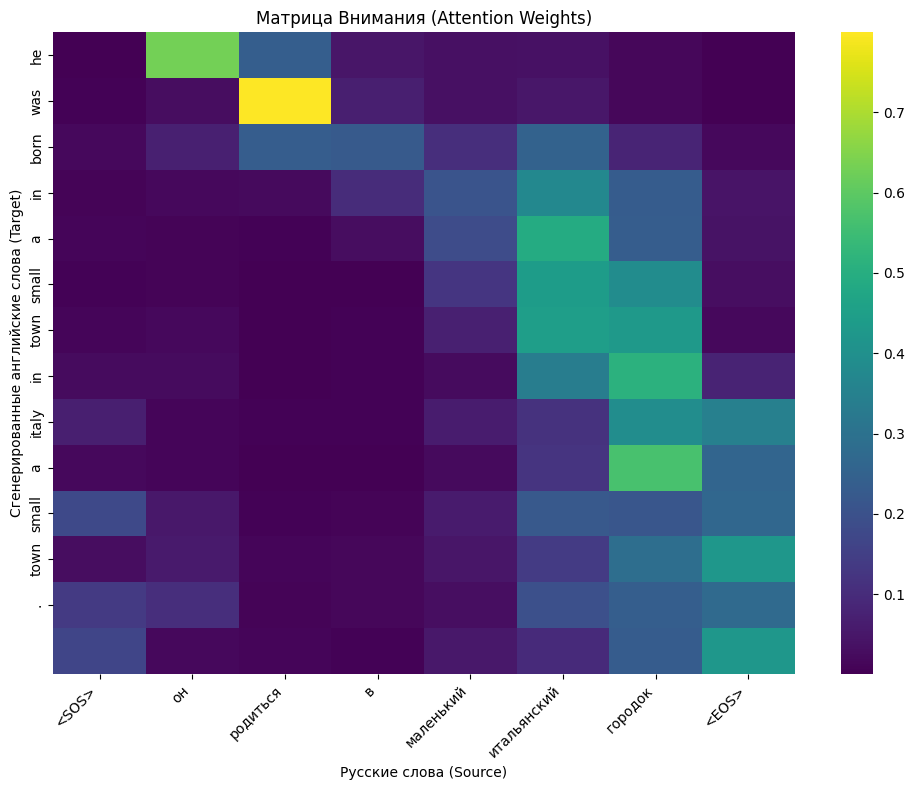

Translation: he was born in a small town in italy a small town .


In [41]:
sample_text = "он родился в маленьком итальянском городке"
sample_text_lemmatized = udobnie_preobrazovaniya(sample_text)

translation = translate_and_show_attention(sample_text_lemmatized, model_attn, ru_tokenizer, en_tokenizer)
print(f"Translation: {translation}")

In [42]:
bleu_metric = BLEUScore()

preds = []
targets  =[]

model_attn.eval()

for idx, row in tqdm(test.iterrows(), total=test.shape[0]):
    src_text = row['rus-lemma']
    true_translation = row['eng-lemma']
    
    pred_translation = translate_and_show_attention(src_text, model_attn, ru_tokenizer, en_tokenizer, False)
    
    preds.append(pred_translation)
    targets.append([true_translation])


bleu_score = bleu_metric(preds, targets)
print(f"Test BLEU Score: {bleu_score.item() * 100:.2f}")

100%|██████████| 6000/6000 [01:01<00:00, 97.81it/s] 


Test BLEU Score: 15.63


12GB собственной видеокарты не хватило для обучения, так что пришлось прибегнуть к возможностям внешних серверов 

In [74]:
enc_attn_nl = Encoder(RU_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_RU)
dec_attn_nl = AttentionDecoder(EN_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, PAD_IDX_EN)

model_attn_nl = AttentionEncoderDecoder(
    encoder=enc_attn_nl, 
    decoder=dec_attn_nl, 
    pad_idx=PAD_IDX_EN, 
    ru_tokenizer=ru_tokenizer, 
    en_tokenizer=en_tokenizer
)

trainer_attn_nl = pl.Trainer(
    max_epochs=10, 
    accelerator='auto', 
    log_every_n_steps=10
)

trainer_attn_nl.fit(model_attn_nl, train_dataloaders=train_loader_nl)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ Encoder          │  5.5 M │ train │     0 │
│ 1 │ decoder   │ AttentionDecoder │  8.0 M │ train │     0 │
│ 2 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 13.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.5 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/miniforge3/envs/ocr-research/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


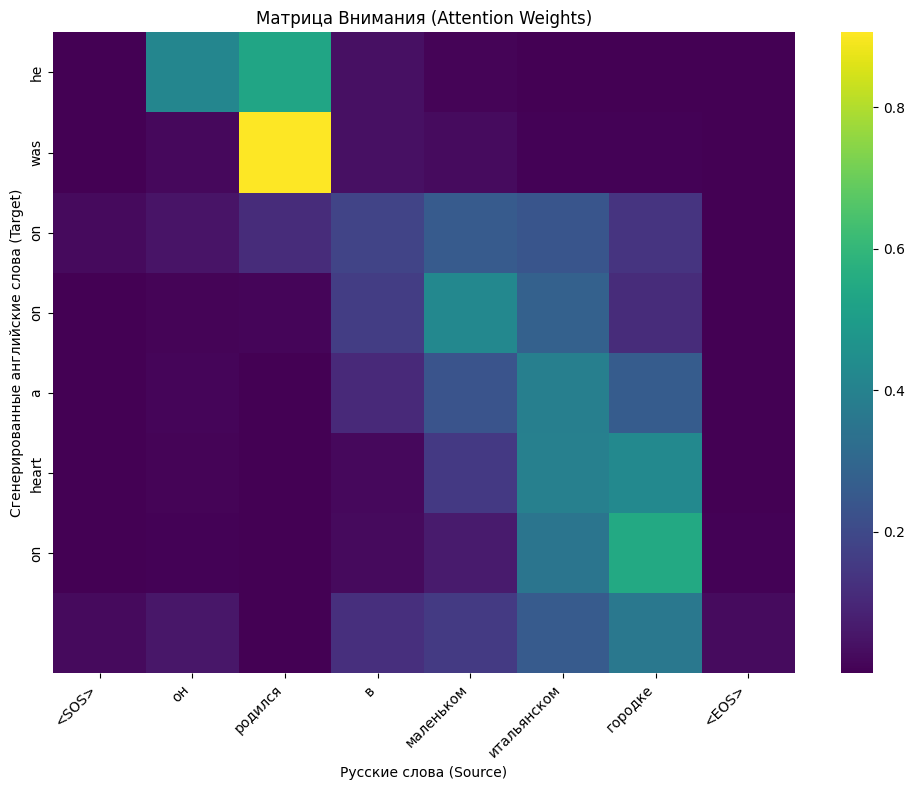

Translation: he was on on a heart on


In [75]:
sample_text = "он родился в маленьком итальянском городке"

translation = translate_and_show_attention(sample_text, model_attn, ru_tokenizer_nl, en_tokenizer_nl)
print(f"Translation: {translation}")

In [ ]:
bleu_metric = BLEUScore()

preds = []
targets  =[]

model_attn.eval()

for idx, row in tqdm(test.iterrows(), total=test.shape[0]):
    src_text = row['rus']
    true_translation = row['eng']
    
    pred_translation = translate_and_show_attention(src_text, model_attn, ru_tokenizer_nl, en_tokenizer_nl, False)
    
    preds.append(pred_translation)
    targets.append([true_translation])


bleu_score = bleu_metric(preds, targets)
print(f"Test BLEU Score: {bleu_score.item() * 100:.2f}")

100%|██████████| 6000/6000 [01:02<00:00, 96.75it/s] 


Test BLEU Score: 0.38
